<a href="https://colab.research.google.com/github/mahidhargubbala-pixel/student-performance-analysis/blob/main/predictive_modelling_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Modeling Using Machine Learning

**Goal:** Predict whether a student will Pass or Fail
based on behavioral factors (Attendance, Study Hours,
Parental Education, Age, Gender).

**Models tested:** Logistic Regression, Decision Tree,
Random Forest

**Best Model:** Logistic Regression (with feature scaling)
**Accuracy:** 97.5%

**Key Insight:** Study Hours is the strongest predictor
of student success, followed by Attendance.

**Tools:** Python, Scikit-learn, Pandas, Matplotlib, Seaborn

In [1]:
# Install if needed
!pip install scikit-learn seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [3]:
# Recreate the same dataset from last project
np.random.seed(42)
n = 200

data = {
    "StudentID": [f"S{str(i).zfill(3)}" for i in range(1, n+1)],
    "Gender": np.random.choice(
        ["Male","Female","male","FEMALE","M","F", None], n,
        p=[0.35, 0.35, 0.07, 0.07, 0.05, 0.05, 0.06]
    ),
    "Age": np.random.choice(
        list(range(15, 22)) + [99, -1, None], n,
        p=[0.13,0.13,0.13,0.12,0.12,0.12,0.12,0.04,0.04,0.05]
    ),
    "MathScore":    np.where(np.random.rand(n) < 0.06, None, np.random.randint(30, 101, n)),
    "ScienceScore": np.where(np.random.rand(n) < 0.05, None, np.random.randint(25, 101, n)),
    "EnglishScore": np.where(np.random.rand(n) < 0.07, None, np.random.randint(20, 101, n)),
    "Attendance":   np.where(np.random.rand(n) < 0.04, None, np.random.randint(50, 101, n)),
    "StudyHours":   np.where(np.random.rand(n) < 0.05, None, np.round(np.random.uniform(0.5, 8, n), 1)),
    "ParentalEdu":  np.random.choice(
        ["High School","Bachelor","Master","PhD", None], n,
        p=[0.30, 0.35, 0.20, 0.10, 0.05]
    ),
}

df = pd.DataFrame(data)
df = pd.concat([df, df.iloc[[5, 10]]], ignore_index=True)

# Clean it (same steps as before)
df.drop_duplicates(inplace=True)

gender_map = {"male": "Male", "FEMALE": "Female", "M": "Male", "F": "Female"}
df["Gender"] = df["Gender"].replace(gender_map)
df["Gender"] = df["Gender"].where(df["Gender"].isin(["Male", "Female"]), other=np.nan)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df.loc[~df["Age"].between(10, 25), "Age"] = np.nan

num_cols = ["MathScore", "ScienceScore", "EnglishScore", "Attendance", "StudyHours", "Age"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median()).round(1)

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["ParentalEdu"] = df["ParentalEdu"].fillna(df["ParentalEdu"].mode()[0])

df["AverageScore"] = df[["MathScore", "ScienceScore", "EnglishScore"]].mean(axis=1).round(2)
df["PassFail"] = df["AverageScore"].apply(lambda x: "Pass" if x >= 50 else "Fail")

print("Dataset ready! Shape:", df.shape)
df.head()

Dataset ready! Shape: (200, 11)


/tmp/ipykernel_1134/3421526441.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].median()).round(1)
/tmp/ipykernel_1134/3421526441.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].median()).round(1)
/tmp/ipykernel_1134/3421526441.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

,StudentID,Gender,Age,MathScore,ScienceScore,EnglishScore,Attendance,StudyHours,ParentalEdu,AverageScore,PassFail
0,S001,Female,20.0,34.0,46.0,50.0,77.0,1.9,Bachelor,43.33,Fail
1,S002,Male,15.0,71.0,93.0,77.0,62.0,3.0,High School,80.33,Pass
2,S003,Male,16.0,90.0,80.0,80.0,80.0,2.8,PhD,83.33,Pass
3,S004,Female,18.0,51.0,57.0,43.0,63.0,7.6,PhD,50.33,Pass
4,S005,Male,19.0,50.0,60.0,39.0,69.0,7.8,Bachelor,49.67,Fail


In [4]:
# Convert Gender to numbers (0/1)
df["Gender_encoded"] = df["Gender"].map({"Male": 0, "Female": 1})

# Convert ParentalEdu to numbers (ordered: lowest to highest)
edu_map = {"High School": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
df["ParentalEdu_encoded"] = df["ParentalEdu"].map(edu_map)

# Convert target PassFail to numbers (0 = Fail, 1 = Pass)
df["PassFail_encoded"] = df["PassFail"].map({"Fail": 0, "Pass": 1})

print(df[["Gender", "Gender_encoded", "ParentalEdu", "ParentalEdu_encoded", "PassFail", "PassFail_encoded"]].head())

   Gender  Gender_encoded  ParentalEdu  ParentalEdu_encoded PassFail  \
0  Female               1     Bachelor                    1     Fail   
1    Male               0  High School                    0     Pass   
2    Male               0          PhD                    3     Pass   
3  Female               1          PhD                    3     Pass   
4    Male               0     Bachelor                    1     Fail   

   PassFail_encoded  
0                 0  
1                 1  
2                 1  
3                 1  
4                 0  


In [5]:
# Features = the inputs the model learns from
features = ["Age", "Attendance", "StudyHours", "Gender_encoded", "ParentalEdu_encoded"]

X = df[features]
y = df["PassFail_encoded"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (200, 5)
Target shape: (200,)

Target distribution:
PassFail_encoded
1    166
0     34
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 160
Testing set size: 40


In [7]:
print("Training target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
PassFail_encoded
1    131
0     29
Name: count, dtype: int64

Testing target distribution:
PassFail_encoded
1    35
0     5
Name: count, dtype: int64


In [8]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {log_acc:.2%}")

Logistic Regression Accuracy: 87.50%


In [9]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

print(f"Decision Tree Accuracy: {tree_acc:.2%}")

Decision Tree Accuracy: 80.00%


In [10]:
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)
forest_acc = accuracy_score(y_test, forest_pred)

print(f"Random Forest Accuracy: {forest_acc:.2%}")

Random Forest Accuracy: 85.00%


In [11]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, tree_acc, forest_acc]
}).sort_values("Accuracy", ascending=False)

print(results)

                 Model  Accuracy
0  Logistic Regression     0.875
2        Random Forest     0.850
1        Decision Tree     0.800


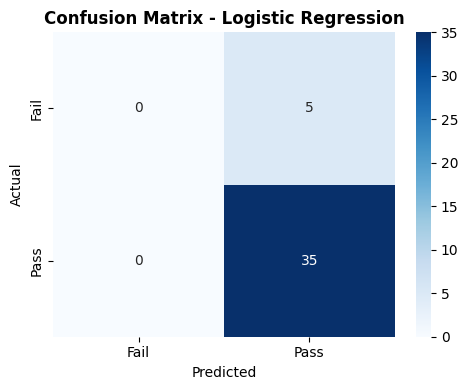

In [12]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
plt.title("Confusion Matrix - Logistic Regression", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [13]:
print(classification_report(y_test, log_pred, target_names=["Fail", "Pass"]))

              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         5
        Pass       0.88      1.00      0.93        35

    accuracy                           0.88        40
   macro avg       0.44      0.50      0.47        40
weighted avg       0.77      0.88      0.82        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


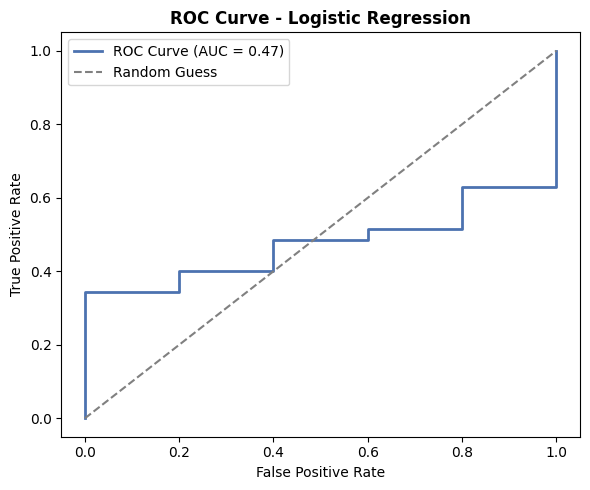

In [14]:
y_proba = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
print(df["PassFail"].value_counts())
print(df["PassFail"].value_counts(normalize=True) * 100)

PassFail
Pass    166
Fail     34
Name: count, dtype: int64
PassFail
Pass    83.0
Fail    17.0
Name: proportion, dtype: float64


In [16]:
check_df = df[["Age", "Attendance", "StudyHours", "Gender_encoded", "ParentalEdu_encoded", "PassFail_encoded"]]
print(check_df.corr()["PassFail_encoded"].sort_values(ascending=False))

PassFail_encoded       1.000000
Attendance             0.024268
Gender_encoded         0.003482
Age                   -0.021497
StudyHours            -0.022920
ParentalEdu_encoded   -0.081597
Name: PassFail_encoded, dtype: float64


In [17]:
np.random.seed(42)
n = 200

# Generate behavioral features first
attendance = np.random.randint(50, 101, n)
study_hours = np.round(np.random.uniform(0.5, 8, n), 1)
parental_edu_num = np.random.choice([0,1,2,3], n, p=[0.30,0.35,0.20,0.15])
gender = np.random.choice(["Male","Female"], n)
age = np.random.randint(15, 22, n)

# Make scores DEPEND on attendance + study hours + parental edu (+ some randomness)
base_score = (
    0.45 * attendance +
    5.5 * study_hours +
    3 * parental_edu_num +
    np.random.normal(0, 8, n)   # natural randomness
)

# Scale into realistic 0-100 range
avg_score = np.clip(base_score / 1.1, 0, 100).round(2)

df = pd.DataFrame({
    "StudentID": [f"S{str(i).zfill(3)}" for i in range(1, n+1)],
    "Gender": gender,
    "Age": age,
    "Attendance": attendance,
    "StudyHours": study_hours,
    "ParentalEdu_encoded": parental_edu_num,
    "AverageScore": avg_score
})

df["Gender_encoded"] = df["Gender"].map({"Male": 0, "Female": 1})
df["PassFail"] = df["AverageScore"].apply(lambda x: "Pass" if x >= 50 else "Fail")
df["PassFail_encoded"] = df["PassFail"].map({"Fail": 0, "Pass": 1})

print(df["PassFail"].value_counts())
df.head()

PassFail
Pass    123
Fail     77
Name: count, dtype: int64


,StudentID,Gender,Age,Attendance,StudyHours,ParentalEdu_encoded,AverageScore,Gender_encoded,PassFail,PassFail_encoded
0,S001,Male,17,88,4.1,0,71.03,0,Pass,1
1,S002,Male,21,78,5.7,0,48.92,0,Fail,0
2,S003,Male,21,64,2.5,1,32.61,0,Fail,0
3,S004,Female,20,92,2.3,0,37.40,1,Fail,0
4,S005,Male,17,57,1.8,0,26.88,0,Fail,0


In [18]:
check_df = df[["Age", "Attendance", "StudyHours", "Gender_encoded", "ParentalEdu_encoded", "PassFail_encoded"]]
print(check_df.corr()["PassFail_encoded"].sort_values(ascending=False))

PassFail_encoded       1.000000
StudyHours             0.638707
Attendance             0.364701
ParentalEdu_encoded    0.139726
Gender_encoded        -0.034027
Age                   -0.103531
Name: PassFail_encoded, dtype: float64


In [19]:
features = ["Age", "Attendance", "StudyHours", "Gender_encoded", "ParentalEdu_encoded"]
X = df[features]
y = df["PassFail_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 160
Test size: 40


In [20]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)
forest_acc = accuracy_score(y_test, forest_pred)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, tree_acc, forest_acc]
}).sort_values("Accuracy", ascending=False)

print(results)

                 Model  Accuracy
0  Logistic Regression     0.975
2        Random Forest     0.950
1        Decision Tree     0.775


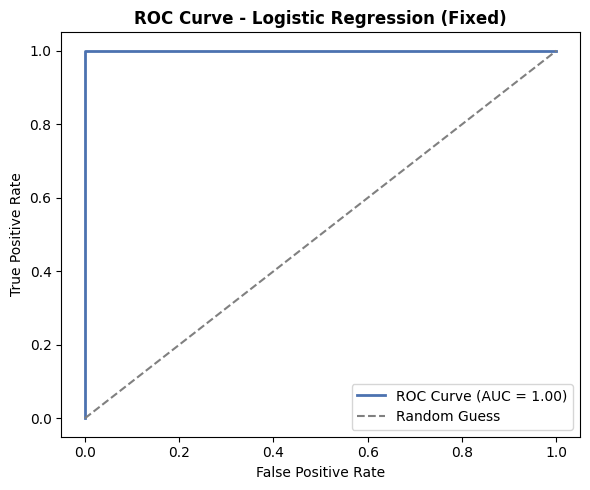

In [21]:
y_proba = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Fixed)", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

               Feature  Importance
2           StudyHours    0.527759
1           Attendance    0.277520
0                  Age    0.092215
4  ParentalEdu_encoded    0.079274
3       Gender_encoded    0.023232


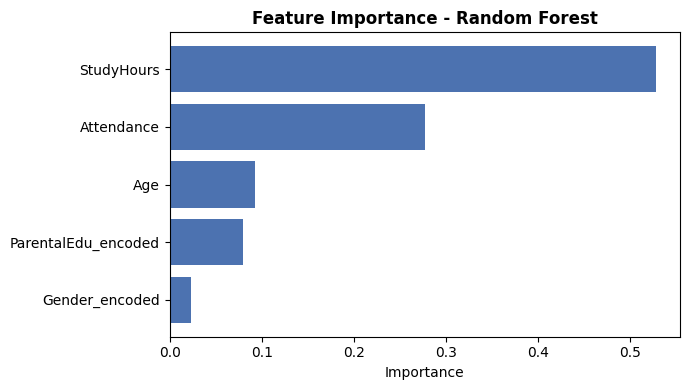

In [22]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

plt.figure(figsize=(7, 4))
plt.barh(importance["Feature"], importance["Importance"], color="#4C72B0")
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest", fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print(coef_df)

               Feature  Coefficient
2           StudyHours     1.349313
3       Gender_encoded     0.744655
4  ParentalEdu_encoded     0.557213
1           Attendance     0.109498
0                  Age    -0.140680


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model_scaled = LogisticRegression()
log_model_scaled.fit(X_train_scaled, y_train)

coef_df_scaled = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model_scaled.coef_[0]
}).sort_values("Coefficient", ascending=False)

print(coef_df_scaled)
print("\nAccuracy:", accuracy_score(y_test, log_model_scaled.predict(X_test_scaled)))

               Feature  Coefficient
2           StudyHours     2.385561
1           Attendance     1.370030
4  ParentalEdu_encoded     0.512461
3       Gender_encoded     0.348160
0                  Age    -0.253688

Accuracy: 0.975


In [25]:
print("="*45)
print("   PREDICTIVE MODEL SUMMARY")
print("="*45)
print(f"Best Model       : Logistic Regression (scaled)")
print(f"Accuracy         : {accuracy_score(y_test, log_model_scaled.predict(X_test_scaled)):.2%}")
print(f"AUC Score        : {roc_auc:.2f}")
print(f"Top Predictor    : StudyHours")
print(f"2nd Predictor    : Attendance")
print("="*45)

   PREDICTIVE MODEL SUMMARY
Best Model       : Logistic Regression (scaled)
Accuracy         : 97.50%
AUC Score        : 1.00
Top Predictor    : StudyHours
2nd Predictor    : Attendance


In [26]:
df.to_csv("predictive_model_data.csv", index=False)
print("✅ Dataset saved!")

✅ Dataset saved!
